# P0 · Follow iteration and unpacking

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.5 · Follow iteration and unpacking

Comprehensions express loops. Unpacking names each element of a returned pair or tuple.

**Prerequisites:** Build a vocabulary

**Predict:** How many adjacent pairs come from four characters?

**Mental model:** Model code often compresses a familiar loop into one expression. Reading it becomes easier when you expand the expression back into its sequence of steps.

<a id="python-loops"></a>

<a data-compat-cell="p0-loops-zip-and-list-comprehensions"></a>

### P0.5.1 · Understand the need

Model code often compresses a familiar loop into one expression. Reading it becomes easier when you expand the expression back into its sequence of steps.

Enumerate supplies positions alongside values. Zip instead walks multiple sequences together and groups their current elements.

A loop variable can be a pair of names. Unpacking gives each part a useful name before the loop body runs.

A comprehension builds a collection immediately. A generator expression supplies values as a consumer requests them, and can be exhausted.

These patterns appear in tokenizers, batch construction, lists of model blocks and parameter counts. Trace a tiny example before reading a long expression.

### P0.5.2 · Follow the values

Enumerating the text pairs every position with its character. The position describes where an occurrence appears, even when the same character appears elsewhere.

Zip the text with its one-position-shifted version. There is no next character after the last position, so the shorter input determines the number of pairs.

Unpack each pair into left and right. The formatted label preserves visible quotes around whitespace.

The comprehension returns exactly the labels created by the explicit append loop. It changes the spelling of the program, not this result.

The generator supplies label lengths to sum. Running the consumer again would find it exhausted; it is not a reusable list.

In [3]:
FRAMES.clear()
change = 0
text = "to be" if not change else "to"
show("Enumerated positions", list(enumerate(text)))
pairs = list(zip(text, text[1:]))
show("Adjacent pairs", pairs)
labels = []
for left, right in pairs:
    labels.append(f"{left!r} -> {right!r}")
show("Unpacked and formatted", labels)
show("Equivalent comprehension", [f"{a!r} -> {b!r}" for a, b in pairs])
lengths = (len(item) for item in labels)
show("Generator consumed by sum", sum(lengths))

Enumerated positions: [[0, "t"], [1, "o"], [2, " "], [3, "b"], [4, "e"]]
Adjacent pairs: [["t", "o"], ["o", " "], [" ", "b"], ["b", "e"]]
Unpacked and formatted: ["'t' -> 'o'", "'o' -> ' '", "' ' -> 'b'", "'b' -> 'e'"]
Equivalent comprehension: ["'t' -> 'o'", "'o' -> ' '", "' ' -> 'b'", "'b' -> 'e'"]
Generator consumed by sum: 40


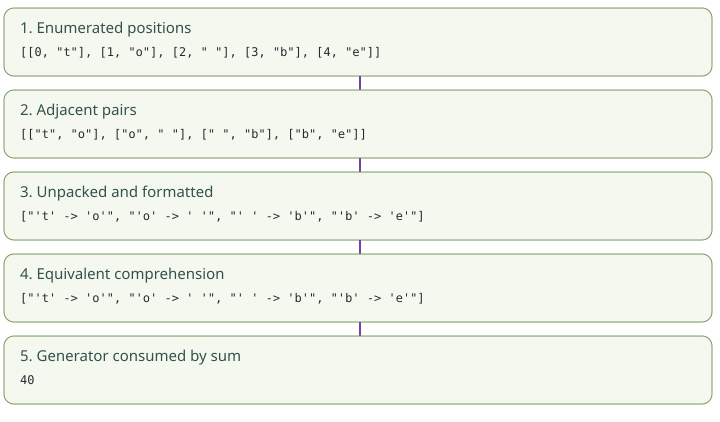

In [4]:
draw_trace()

### P0.5.3 · Read and run the code

Enumerate and zip return iterators. Convert them to lists here so the complete small result can be inspected more than once.

In the loop header, two names receive the two items of each pair. Mismatched unpacking lengths raise an error rather than silently dropping values.

Read a comprehension in execution order: for each pair, unpack it, calculate the label, then collect the label.

A generator uses parentheses and produces items lazily. Sum consumes each supplied number and accumulates a total.

Range excludes its stopping boundary. Break leaves the current loop; neither operation changes how the next-target offset is defined.

### Change one thing

**Shorten the text to two characters**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be" if not change else "to"
show("Enumerated positions", list(enumerate(text)))
pairs = list(zip(text, text[1:]))
show("Adjacent pairs", pairs)
labels = []
for left, right in pairs:
    labels.append(f"{left!r} -> {right!r}")
show("Unpacked and formatted", labels)
show("Equivalent comprehension", [f"{a!r} -> {b!r}" for a, b in pairs])
lengths = (len(item) for item in labels)
show("Generator consumed by sum", sum(lengths))

Enumerated positions: [[0, "t"], [1, "o"]]
Adjacent pairs: [["t", "o"]]
Unpacked and formatted: ["'t' -> 'o'"]
Equivalent comprehension: ["'t' -> 'o'"]
Generator consumed by sum: 10


### A useful distinction

zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.

In [6]:
g = (i * i for i in range(3))
assert list(g) == [0, 1, 4]
assert list(g) == []
try:
    list(zip([1, 2], [3], strict=True))
except ValueError:
    print("strict zip detects unequal lengths.")

strict zip detects unequal lengths.


### ✋ Your turn

For "abcd", use zip and a shifted slice to put the adjacent pairs in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [("a", "b"), ("b", "c"), ("c", "d")], 'zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = list(zip("abcd", "abcd"[1:]))

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [("a", "b"), ("b", "c"), ("c", "d")], 'zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.'
    print("✓ right:", answer)

✓ right: [('a', 'b'), ('b', 'c'), ('c', 'd')]


### P0.5.4 · Find it in the model

The tokenizer encodes text with a comprehension. The training sampler builds a list of windows, then stacks those windows into a batch.

Parameter counting uses a generator: ask each parameter for its number of elements, then sum those counts. No intermediate list is required.

The model constructs repeated blocks with a comprehension and passes them into a container. Each constructor call creates a distinct block unless sharing is explicitly requested.

An attention expression can apply the same reshape to query, key and value tensors. Unpacking names the three returned results.

Next, give these transformations clear function boundaries so inputs and outputs remain understandable.

```python
sum(p.numel() for p in model.parameters())
[Block(cfg) for _ in range(cfg.n_layer)]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** How many adjacent pairs come from four characters?

<details><summary>Check your explanation</summary>

3. zip stops at the shortest input by default. A consumed generator cannot be replayed like a list.

</details>